# Аналіз Schedule Structure Experiment

Цей notebook аналізує один BehaviourSpace-експеримент, у якому варіюються:

- `reward-cycles`
- `reward-duration`

Інші параметри зафіксовані.

Основні цільові сценарії:

- No reward
- Single 60
- Repeated 3×20
- Single 120
- Repeated 3×40

Notebook:

- читає NetLogo Table output;
- перевіряє структуру даних;
- формує збалансований набір цільових сценаріїв;
- залишає окремий повний набір для додаткового аналізу;
- порівнює фінальну поведінку, intrinsic motivation та habit;
- оцінює ефект структури програми за однакової сумарної тривалості винагороди;
- виконує ANOVA;
- експортує таблиці та графіки.

## Підготовка середовища

```bash
python -m pip install pandas numpy matplotlib statsmodels scipy
```

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

OUTPUT_DIR = Path("./analysis_output/schedule_structure")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: /Users/igor/projects/phd/reward-habits-model/analysis_output_schedule_structure


## Налаштування

Зміни `CSV_PATH`, якщо файл має іншу назву.

In [2]:
CSV_PATH = Path("./experiments/3-schedule-structure/table.csv")

PRIMARY_TARGET = "high-reward-crowding-out-effect"
SECONDARY_TARGET = "low-reward-persistence-effect"

FINAL_WITHDRAWAL_METRICS = [
    'final-withdrawal-choice-rate "control"',
    'final-withdrawal-choice-rate "low-salience"',
    'final-withdrawal-choice-rate "high-salience"',
]

INTER_CYCLE_METRICS = [
    'inter-cycle-choice-rate "control"',
    'inter-cycle-choice-rate "low-salience"',
    'inter-cycle-choice-rate "high-salience"',
]

MOTIVATION_METRICS = [
    'mean-intrinsic-motivation "control"',
    'mean-intrinsic-motivation "low-salience"',
    'mean-intrinsic-motivation "high-salience"',
]

HABIT_METRICS = [
    'mean-habit "control"',
    'mean-habit "low-salience"',
    'mean-habit "high-salience"',
]

## Завантаження NetLogo Table output

BehaviourSpace Table output читається з пропуском перших шести службових рядків.

In [3]:
df = pd.read_csv(CSV_PATH, skiprows=6)
df.columns = df.columns.astype(str).str.strip()

print("Shape:", df.shape)
print("\nColumns:")
for column in df.columns:
    print("-", column)

df.head()

Shape: (360, 24)

Columns:
- [run number]
- reward-cycles
- reward-duration
- withdrawal-duration
- number-of-shoppers
- low-reward-salience
- high-reward-salience
- habit-learning-rate
- crowding-out-rate
- [step]
- final-withdrawal-choice-rate "control"
- final-withdrawal-choice-rate "low-salience"
- final-withdrawal-choice-rate "high-salience"
- inter-cycle-choice-rate "control"
- inter-cycle-choice-rate "low-salience"
- inter-cycle-choice-rate "high-salience"
- high-reward-crowding-out-effect
- low-reward-persistence-effect
- mean-intrinsic-motivation "control"
- mean-intrinsic-motivation "low-salience"
- mean-intrinsic-motivation "high-salience"
- mean-habit "control"
- mean-habit "low-salience"
- mean-habit "high-salience"


,[run number],reward-cycles,reward-duration,withdrawal-duration,number-of-shoppers,low-reward-salience,high-reward-salience,habit-learning-rate,crowding-out-rate,[step],"final-withdrawal-choice-rate ""control""","final-withdrawal-choice-rate ""low-salience""","final-withdrawal-choice-rate ""high-salience""","inter-cycle-choice-rate ""control""","inter-cycle-choice-rate ""low-salience""","inter-cycle-choice-rate ""high-salience""",high-reward-crowding-out-effect,low-reward-persistence-effect,"mean-intrinsic-motivation ""control""","mean-intrinsic-motivation ""low-salience""","mean-intrinsic-motivation ""high-salience""","mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience"""
0,2,0,20,30,1000,0.3,0.9,0.02,0.03,60,0.684431,0.658458,0.664565,0.0,0.0,0.0,-0.019867,-0.025973,0.503354,0.495199,0.489582,0.622480,0.601914,0.598798
1,6,0,20,30,1000,0.3,0.9,0.02,0.03,60,0.669860,0.664865,0.674174,0.0,0.0,0.0,0.004314,-0.004995,0.500579,0.487643,0.500406,0.606215,0.605059,0.615753
2,8,0,20,30,1000,0.3,0.9,0.02,0.03,60,0.666766,0.686787,0.691792,0.0,0.0,0.0,0.025025,0.020020,0.484715,0.504105,0.510446,0.600713,0.617406,0.629542
3,5,0,20,30,1000,0.3,0.9,0.02,0.03,60,0.665269,0.667367,0.668969,0.0,0.0,0.0,0.003700,0.002098,0.500377,0.496078,0.499737,0.602696,0.604694,0.602706
4,7,0,20,30,1000,0.3,0.9,0.02,0.03,60,0.688323,0.659359,0.681081,0.0,0.0,0.0,-0.007242,-0.028964,0.507143,0.492424,0.502368,0.620497,0.596817,0.614553


## Перевірка структури

In [4]:
required_columns = [
    "[run number]",
    "reward-cycles",
    "reward-duration",
    "withdrawal-duration",
    "number-of-shoppers",
    "low-reward-salience",
    "high-reward-salience",
    "habit-learning-rate",
    "crowding-out-rate",
    PRIMARY_TARGET,
    SECONDARY_TARGET,
    *FINAL_WITHDRAWAL_METRICS,
    *INTER_CYCLE_METRICS,
    *MOTIVATION_METRICS,
    *HABIT_METRICS,
]

missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    print("Відсутні колонки:")
    for column in missing_columns:
        print("-", column)
else:
    print("Усі очікувані колонки присутні.")

Усі очікувані колонки присутні.


## Очищення даних

In [5]:
numeric_columns = [
    "reward-cycles",
    "reward-duration",
    "withdrawal-duration",
    "number-of-shoppers",
    "low-reward-salience",
    "high-reward-salience",
    "habit-learning-rate",
    "crowding-out-rate",
    PRIMARY_TARGET,
    SECONDARY_TARGET,
    *FINAL_WITHDRAWAL_METRICS,
    *INTER_CYCLE_METRICS,
    *MOTIVATION_METRICS,
    *HABIT_METRICS,
]

clean_df = df.copy()

for column in numeric_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

before_rows = len(clean_df)

clean_df = clean_df.dropna(
    subset=[
        "reward-cycles",
        "reward-duration",
        PRIMARY_TARGET,
        SECONDARY_TARGET,
    ]
).copy()

print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", len(clean_df))
print("Removed rows:", before_rows - len(clean_df))

Rows before cleaning: 360
Rows after cleaning: 360
Removed rows: 0


## Перевірка дизайну експерименту

In [6]:
design_counts = (
    clean_df.groupby(["reward-cycles", "reward-duration"])
    .size()
    .reset_index(name="repetitions")
)

print("Combinations:", len(design_counts))
print("Minimum repetitions:", design_counts["repetitions"].min())
print("Maximum repetitions:", design_counts["repetitions"].max())

design_counts

Combinations: 12
Minimum repetitions: 30
Maximum repetitions: 30


,reward-cycles,reward-duration,repetitions
0,0,20,30
1,0,40,30
2,0,60,30
3,0,120,30
4,1,20,30
5,1,40,30
6,1,60,30
7,1,120,30
8,3,20,30
9,3,40,30


## Формування назв сценаріїв

Повний набір містить також додаткові комбінації, які не входять до основного порівняння.

Цільові сценарії:

- `reward-cycles = 0` і `reward-duration = 20` → No reward
- `1 × 60` → Single 60
- `3 × 20` → Repeated 3×20
- `1 × 120` → Single 120
- `3 × 40` → Repeated 3×40

In [7]:
def assign_scenario(row):
    cycles = int(row["reward-cycles"])
    duration = int(row["reward-duration"])

    if cycles == 0 and duration == 20:
        return "No reward"
    if cycles == 1 and duration == 60:
        return "Single 60"
    if cycles == 3 and duration == 20:
        return "Repeated 3×20"
    if cycles == 1 and duration == 120:
        return "Single 120"
    if cycles == 3 and duration == 40:
        return "Repeated 3×40"

    return "Other"


clean_df["scenario"] = clean_df.apply(assign_scenario, axis=1)

scenario_order = [
    "No reward",
    "Single 60",
    "Repeated 3×20",
    "Single 120",
    "Repeated 3×40",
]

target_df = clean_df[clean_df["scenario"] != "Other"].copy()
target_df["scenario"] = pd.Categorical(
    target_df["scenario"],
    categories=scenario_order,
    ordered=True,
)

print("Full dataset shape:", clean_df.shape)
print("Target dataset shape:", target_df.shape)

target_df["scenario"].value_counts().sort_index()

Full dataset shape: (360, 25)
Target dataset shape: (150, 25)


scenario
No reward        30
Single 60        30
Repeated 3×20    30
Single 120       30
Repeated 3×40    30
Name: count, dtype: int64

## Перевірка збалансованості цільового набору

In [8]:
target_counts = (
    target_df.groupby("scenario", observed=False)
    .size()
    .reset_index(name="repetitions")
)

target_counts

,scenario,repetitions
0,No reward,30
1,Single 60,30
2,Repeated 3×20,30
3,Single 120,30
4,Repeated 3×40,30


In [9]:
if target_counts["repetitions"].nunique() == 1:
    print("Цільовий дизайн збалансований.")
else:
    print("Увага: кількість повторень відрізняється між сценаріями.")

Цільовий дизайн збалансований.


## Описова статистика цільових сценаріїв

In [10]:
summary_columns = [
    PRIMARY_TARGET,
    SECONDARY_TARGET,
    *FINAL_WITHDRAWAL_METRICS,
    *MOTIVATION_METRICS,
    *HABIT_METRICS,
]

scenario_summary = (
    target_df.groupby("scenario", observed=False)[summary_columns]
    .agg(["mean", "std", "median", "count"])
)

scenario_summary

high-reward-crowding-out-effect                           low-reward-persistence-effect                           final-withdrawal-choice-rate "control"            \
                                         mean       std    median count                          mean       std    median count                                   mean       std   
scenario                                                                                                                                                                           
No reward                            0.001303  0.014028  0.003520    30                     -0.002684  0.015049 -0.001984    30                               0.674953  0.009201   
Single 60                           -0.052233  0.012153 -0.050391    30                      0.061006  0.012700  0.059898    30                               0.732931  0.008728   
Repeated 3×20                       -0.076473  0.009706 -0.076598    30                      0.047818  0.009062  0.048116    30                               0.756743  0.007173   
Single 120                          -0.147207  0.010090 -0.148161    30                      0.079069  0.010799  0.078511    30                               0.754584  0.009134   
Repeated 3×40                       -0.164128  0.011199 -0.162862    30                      0.068061  0.010079  0.068409    30                               0.767488  0.008311   

                              final-withdrawal-choice-rate "low-salience"                           final-withdrawal-choice-rate "high-salience"                            \
                 median count                                        mean       std    median count                                         mean       std    median count   
scenario                                                                                                                                                                     
No reward      0.676697    30                                    0.672269  0.009535  0.674074    30                                     0.676256  0.008895  0.675225    30   
Single 60      0.732285    30                                    0.793937  0.006819  0.792643    30                                     0.680697  0.006328  0.681732    30   
Repeated 3×20  0.757236    30                                    0.804561  0.005232  0.806106    30                                     0.680270  0.006632  0.680030    30   
Single 120     0.756737    30                                    0.833654  0.004668  0.833483    30                                     0.607377  0.004656  0.606857    30   
Repeated 3×40  0.767016    30                                    0.835549  0.004882  0.835285    30                                     0.603360  0.005411  0.602503    30   

              mean-intrinsic-motivation "control"                           mean-intrinsic-motivation "low-salience"                            \
                                             mean       std    median count                                     mean       std    median count   
scenario                                                                                                                                         
No reward                                0.499809  0.008224  0.501377    30                                 0.498539  0.008185  0.499158    30   
Single 60                                0.499541  0.007119  0.499378    30                                 0.545152  0.008613  0.542932    30   
Repeated 3×20                            0.500473  0.008406  0.500639    30                                 0.547751  0.006351  0.548337    30   
Single 120                               0.497274  0.007916  0.495613    30                                 0.590863  0.005898  0.590328    30   
Repeated 3×40                            0.501614  0.007577  0.500589    30                                 0.590774  0.006285  0.589454    30   

           

## Основний KPI: high-reward crowding-out effect

Негативне значення означає, що після завершення програми high-salience група обирає цільову поведінку рідше, ніж контрольна група.

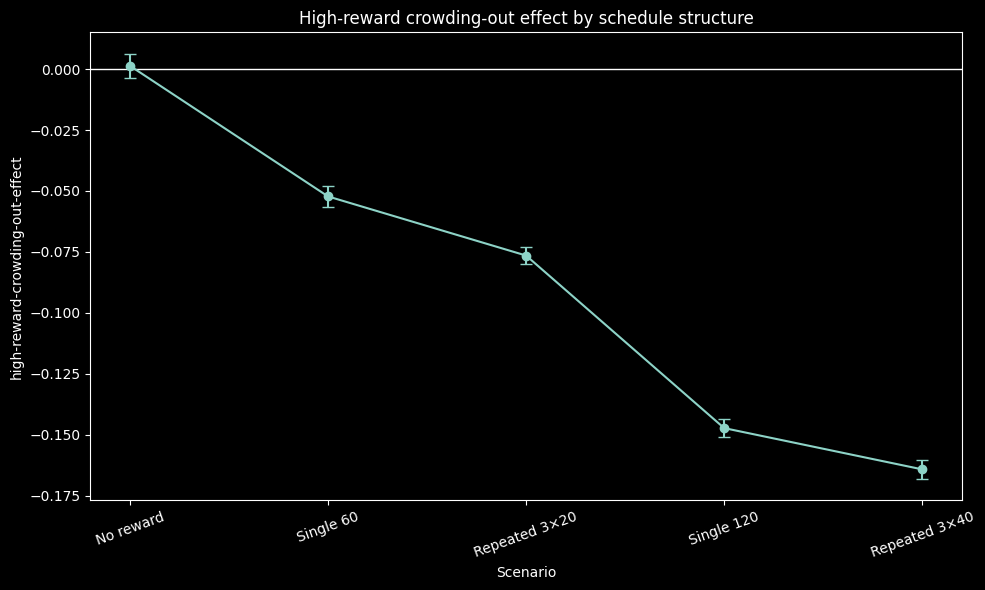

,scenario,mean,std,count,se,ci95
0,No reward,0.001303,0.014028,30,0.002561,0.005020
1,Single 60,-0.052233,0.012153,30,0.002219,0.004349
2,Repeated 3×20,-0.076473,0.009706,30,0.001772,0.003473
3,Single 120,-0.147207,0.010090,30,0.001842,0.003611
4,Repeated 3×40,-0.164128,0.011199,30,0.002045,0.004007


In [11]:
primary_summary = (
    target_df.groupby("scenario", observed=False)[PRIMARY_TARGET]
    .agg(["mean", "std", "count"])
    .reset_index()
)

primary_summary["se"] = primary_summary["std"] / np.sqrt(primary_summary["count"])
primary_summary["ci95"] = 1.96 * primary_summary["se"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    primary_summary["scenario"].astype(str),
    primary_summary["mean"],
    yerr=primary_summary["ci95"],
    marker="o",
    capsize=4,
)

ax.axhline(0, linewidth=1)
ax.set_title("High-reward crowding-out effect by schedule structure")
ax.set_xlabel("Scenario")
ax.set_ylabel(PRIMARY_TARGET)
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "primary_effect_by_scenario.png", dpi=200)
plt.show()

primary_summary

## Порівняння фінальної поведінки трьох груп

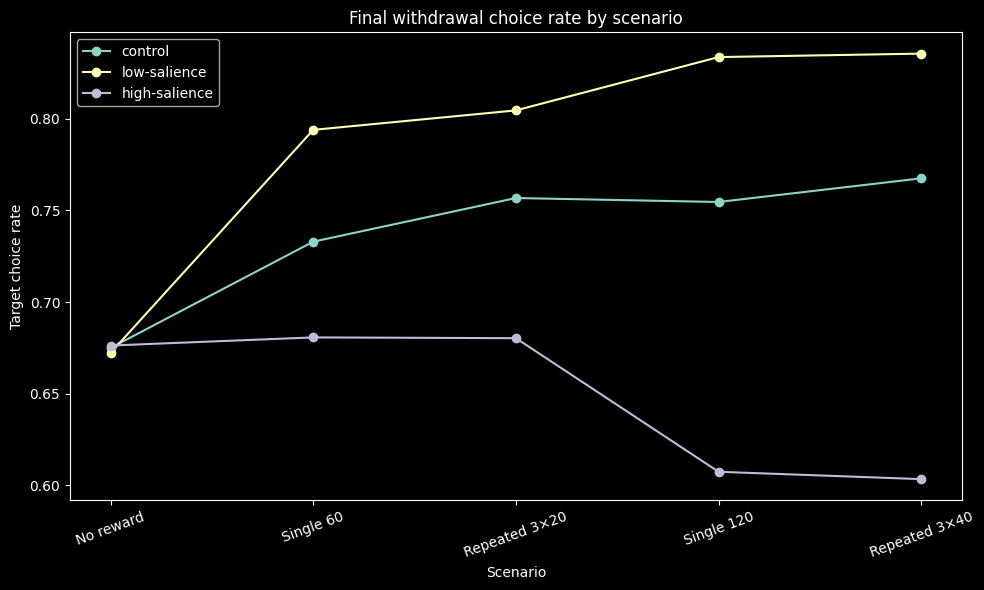

,scenario,"final-withdrawal-choice-rate ""control""","final-withdrawal-choice-rate ""low-salience""","final-withdrawal-choice-rate ""high-salience"""
0,No reward,0.674953,0.672269,0.676256
1,Single 60,0.732931,0.793937,0.680697
2,Repeated 3×20,0.756743,0.804561,0.680270
3,Single 120,0.754584,0.833654,0.607377
4,Repeated 3×40,0.767488,0.835549,0.603360


In [12]:
final_rate_summary = (
    target_df.groupby("scenario", observed=False)[FINAL_WITHDRAWAL_METRICS]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

for metric in FINAL_WITHDRAWAL_METRICS:
    label = (
        metric
        .replace('final-withdrawal-choice-rate "', "")
        .replace('"', "")
    )

    ax.plot(
        final_rate_summary["scenario"].astype(str),
        final_rate_summary[metric],
        marker="o",
        label=label,
    )

ax.set_title("Final withdrawal choice rate by scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Target choice rate")
ax.tick_params(axis="x", rotation=20)
ax.legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "final_withdrawal_rates_by_scenario.png", dpi=200)
plt.show()

final_rate_summary

## Порівняння intrinsic motivation

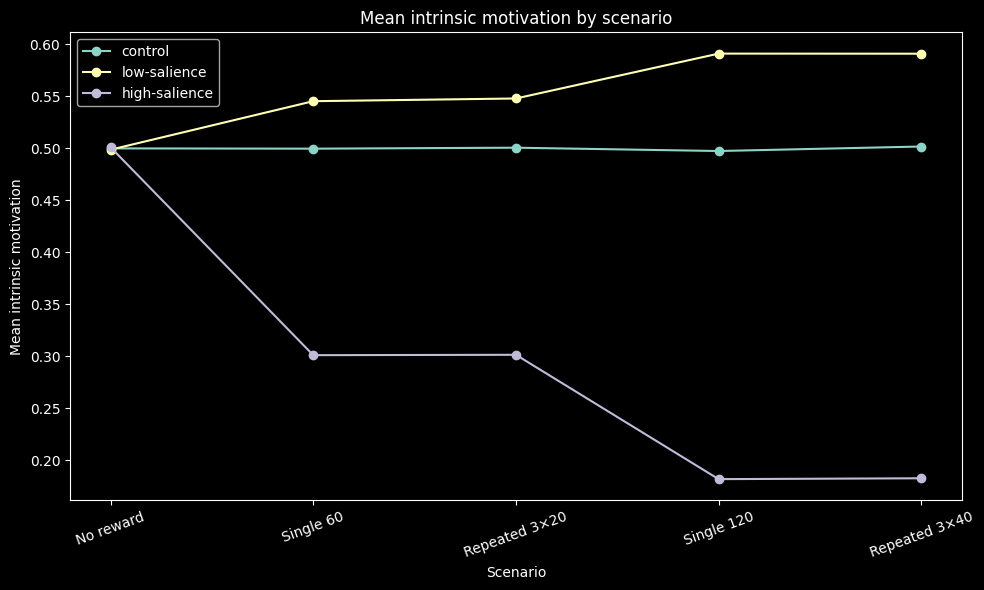

,scenario,"mean-intrinsic-motivation ""control""","mean-intrinsic-motivation ""low-salience""","mean-intrinsic-motivation ""high-salience"""
0,No reward,0.499809,0.498539,0.500908
1,Single 60,0.499541,0.545152,0.301154
2,Repeated 3×20,0.500473,0.547751,0.301508
3,Single 120,0.497274,0.590863,0.182053
4,Repeated 3×40,0.501614,0.590774,0.182884


In [13]:
motivation_summary = (
    target_df.groupby("scenario", observed=False)[MOTIVATION_METRICS]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

for metric in MOTIVATION_METRICS:
    label = (
        metric
        .replace('mean-intrinsic-motivation "', "")
        .replace('"', "")
    )

    ax.plot(
        motivation_summary["scenario"].astype(str),
        motivation_summary[metric],
        marker="o",
        label=label,
    )

ax.set_title("Mean intrinsic motivation by scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Mean intrinsic motivation")
ax.tick_params(axis="x", rotation=20)
ax.legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "intrinsic_motivation_by_scenario.png", dpi=200)
plt.show()

motivation_summary

## Порівняння habit strength

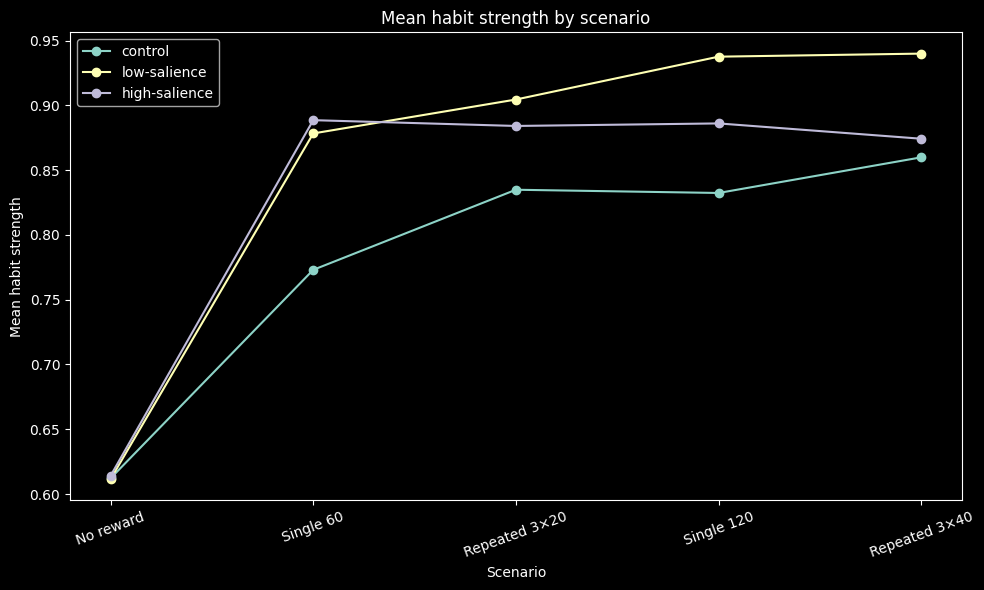

,scenario,"mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience"""
0,No reward,0.612108,0.611485,0.614053
1,Single 60,0.773083,0.878388,0.888637
2,Repeated 3×20,0.834919,0.904575,0.884162
3,Single 120,0.832421,0.937659,0.886124
4,Repeated 3×40,0.859939,0.940021,0.874303


In [14]:
habit_summary = (
    target_df.groupby("scenario", observed=False)[HABIT_METRICS]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

for metric in HABIT_METRICS:
    label = (
        metric
        .replace('mean-habit "', "")
        .replace('"', "")
    )

    ax.plot(
        habit_summary["scenario"].astype(str),
        habit_summary[metric],
        marker="o",
        label=label,
    )

ax.set_title("Mean habit strength by scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Mean habit strength")
ax.tick_params(axis="x", rotation=20)
ax.legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "habit_strength_by_scenario.png", dpi=200)
plt.show()

habit_summary

## Проміжні withdrawal-періоди

Для single-сценаріїв ці метрики можуть бути нульовими або неінформативними. Основний зміст вони мають для repeated-сценаріїв.

In [15]:
inter_cycle_summary = (
    target_df.groupby("scenario", observed=False)[INTER_CYCLE_METRICS]
    .mean()
    .reset_index()
)

inter_cycle_summary

,scenario,"inter-cycle-choice-rate ""control""","inter-cycle-choice-rate ""low-salience""","inter-cycle-choice-rate ""high-salience"""
0,No reward,0.000000,0.00000,0.000000
1,Single 60,0.000000,0.00000,0.000000
2,Repeated 3×20,0.721835,0.75861,0.708262
3,Single 120,0.000000,0.00000,0.000000
4,Repeated 3×40,0.740414,0.79353,0.678118


## Контрольовані парні порівняння

Головні порівняння:

- Single 60 vs Repeated 3×20
- Single 120 vs Repeated 3×40

У кожній парі сумарна тривалість дії винагороди однакова.

In [16]:
def compare_scenarios(data, scenario_a, scenario_b, metric):
    values_a = data.loc[data["scenario"] == scenario_a, metric].dropna()
    values_b = data.loc[data["scenario"] == scenario_b, metric].dropna()

    test = stats.ttest_ind(values_a, values_b, equal_var=False)

    difference = values_b.mean() - values_a.mean()

    pooled_sd = np.sqrt(
        (
            ((len(values_a) - 1) * values_a.var(ddof=1))
            + ((len(values_b) - 1) * values_b.var(ddof=1))
        )
        / (len(values_a) + len(values_b) - 2)
    )

    cohens_d = difference / pooled_sd if pooled_sd != 0 else np.nan

    return {
        "scenario_a": scenario_a,
        "scenario_b": scenario_b,
        "metric": metric,
        "mean_a": values_a.mean(),
        "mean_b": values_b.mean(),
        "difference_b_minus_a": difference,
        "t_statistic": test.statistic,
        "p_value": test.pvalue,
        "cohens_d": cohens_d,
    }


pairwise_results = pd.DataFrame([
    compare_scenarios(
        target_df,
        "Single 60",
        "Repeated 3×20",
        PRIMARY_TARGET,
    ),
    compare_scenarios(
        target_df,
        "Single 120",
        "Repeated 3×40",
        PRIMARY_TARGET,
    ),
])

pairwise_results

,scenario_a,scenario_b,metric,mean_a,mean_b,difference_b_minus_a,t_statistic,p_value,cohens_d
0,Single 60,Repeated 3×20,high-reward-crowding-out-effect,-0.052233,-0.076473,-0.024239,8.536472,1.126699e-11,-2.204107
1,Single 120,Repeated 3×40,high-reward-crowding-out-effect,-0.147207,-0.164128,-0.016922,6.148718,8.019514e-08,-1.587592


## Парні порівняння для фінальної частоти вибору

In [17]:
high_final_metric = 'final-withdrawal-choice-rate "high-salience"'

final_rate_pairwise = pd.DataFrame([
    compare_scenarios(
        target_df,
        "Single 60",
        "Repeated 3×20",
        high_final_metric,
    ),
    compare_scenarios(
        target_df,
        "Single 120",
        "Repeated 3×40",
        high_final_metric,
    ),
])

final_rate_pairwise

,scenario_a,scenario_b,metric,mean_a,mean_b,difference_b_minus_a,t_statistic,p_value,cohens_d
0,Single 60,Repeated 3×20,"final-withdrawal-choice-rate ""high-salience""",0.680697,0.68027,-0.000427,0.255185,0.799485,-0.065888
1,Single 120,Repeated 3×40,"final-withdrawal-choice-rate ""high-salience""",0.607377,0.60336,-0.004017,3.082428,0.003167,-0.795879


## Однофакторна ANOVA за сценаріями

In [18]:
anova_df = target_df.copy()
anova_df["scenario_text"] = anova_df["scenario"].astype(str)

anova_model = smf.ols(
    f'Q("{PRIMARY_TARGET}") ~ C(scenario_text)',
    data=anova_df,
).fit()

anova_table = anova_lm(anova_model, typ=2)

anova_table["eta_squared"] = (
    anova_table["sum_sq"] / anova_table["sum_sq"].sum()
)

anova_table

,sum_sq,df,F,PR(>F),eta_squared
C(scenario_text),0.560633,4.0,1052.42389,5.327500e-106,0.966703
Residual,0.019311,145.0,NaN,NaN,0.033297


## Tukey HSD

Показує, між якими сценаріями є статистично значущі відмінності.

In [19]:
tukey = pairwise_tukeyhsd(
    endog=target_df[PRIMARY_TARGET],
    groups=target_df["scenario"].astype(str),
    alpha=0.05,
)

print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2    meandiff p-adj  lower   upper  reject
-----------------------------------------------------------------
    No reward Repeated 3×20  -0.0778   0.0  -0.086 -0.0695   True
    No reward Repeated 3×40  -0.1654   0.0 -0.1737 -0.1572   True
    No reward    Single 120  -0.1485   0.0 -0.1567 -0.1403   True
    No reward     Single 60  -0.0535   0.0 -0.0618 -0.0453   True
Repeated 3×20 Repeated 3×40  -0.0877   0.0 -0.0959 -0.0794   True
Repeated 3×20    Single 120  -0.0707   0.0  -0.079 -0.0625   True
Repeated 3×20     Single 60   0.0242   0.0   0.016  0.0325   True
Repeated 3×40    Single 120   0.0169   0.0  0.0087  0.0252   True
Repeated 3×40     Single 60   0.1119   0.0  0.1037  0.1201   True
   Single 120     Single 60    0.095   0.0  0.0867  0.1032   True
-----------------------------------------------------------------


## Ймовірність crowding-out за сценаріями

In [20]:
crowding_probability = (
    target_df.assign(
        crowding_out=target_df[PRIMARY_TARGET] < 0
    )
    .groupby("scenario", observed=False)["crowding_out"]
    .agg(["mean", "sum", "count"])
    .reset_index()
    .rename(columns={"mean": "crowding_probability"})
)

crowding_probability

,scenario,crowding_probability,sum,count
0,No reward,0.433333,13,30
1,Single 60,1.000000,30,30
2,Repeated 3×20,1.000000,30,30
3,Single 120,1.000000,30,30
4,Repeated 3×40,1.000000,30,30


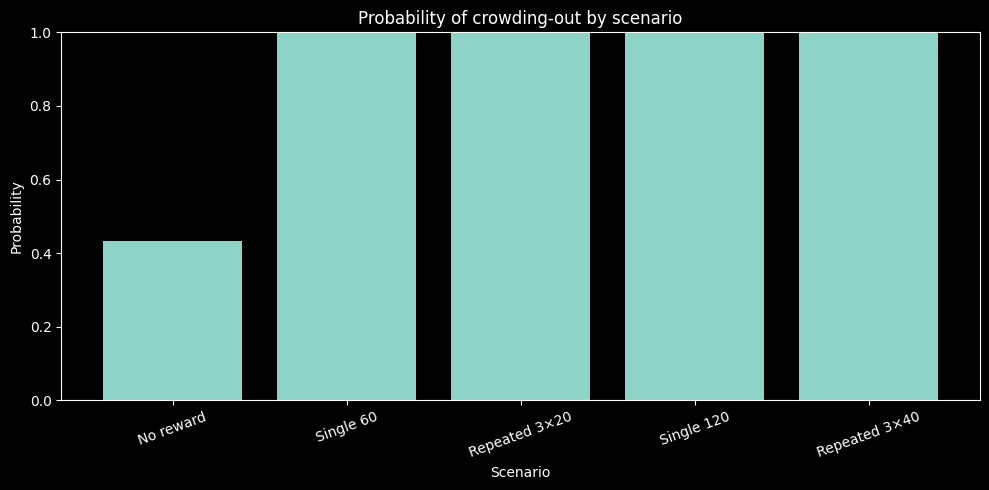

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    crowding_probability["scenario"].astype(str),
    crowding_probability["crowding_probability"],
)

ax.set_title("Probability of crowding-out by scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "crowding_probability_by_scenario.png", dpi=200)
plt.show()

## Додатковий аналіз повного набору

Цей блок використовує всі 12 комбінацій `reward-cycles × reward-duration`.

In [22]:
full_summary = (
    clean_df.groupby(["reward-cycles", "reward-duration"])
    .agg(
        mean_crowding_effect=(PRIMARY_TARGET, "mean"),
        std_crowding_effect=(PRIMARY_TARGET, "std"),
        mean_low_persistence=(SECONDARY_TARGET, "mean"),
        runs=(PRIMARY_TARGET, "size"),
    )
    .reset_index()
)

full_summary

,reward-cycles,reward-duration,mean_crowding_effect,std_crowding_effect,mean_low_persistence,runs
0,0,20,0.001303,0.014028,-0.002684,30
1,0,40,-0.000137,0.014404,0.000224,30
2,0,60,-0.001259,0.010809,0.000576,30
3,0,120,0.001211,0.013770,0.001558,30
4,1,20,0.007452,0.010913,0.030788,30
5,1,40,-0.018842,0.009620,0.053777,30
6,1,60,-0.052233,0.012153,0.061006,30
7,1,120,-0.147207,0.010090,0.079069,30
8,3,20,-0.076473,0.009706,0.047818,30
9,3,40,-0.164128,0.011199,0.068061,30


## Heatmap повного набору

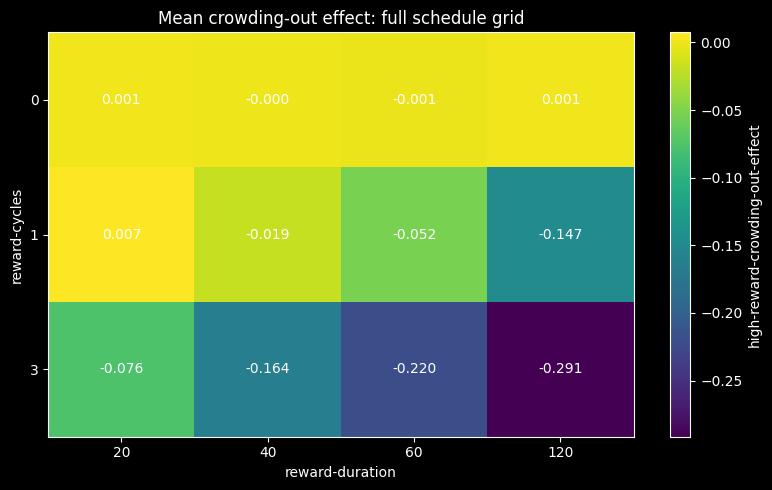

reward-duration,20,40,60,120
reward-cycles,,,,
0,0.001303,-0.000137,-0.001259,0.001211
1,0.007452,-0.018842,-0.052233,-0.147207
3,-0.076473,-0.164128,-0.219883,-0.291460


In [23]:
heatmap = clean_df.pivot_table(
    values=PRIMARY_TARGET,
    index="reward-cycles",
    columns="reward-duration",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(heatmap.values, aspect="auto")

ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)

ax.set_xlabel("reward-duration")
ax.set_ylabel("reward-cycles")
ax.set_title("Mean crowding-out effect: full schedule grid")

for row in range(heatmap.shape[0]):
    for column in range(heatmap.shape[1]):
        value = heatmap.iloc[row, column]
        ax.text(column, row, f"{value:.3f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label=PRIMARY_TARGET)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heatmap_full_schedule_grid.png", dpi=200)
plt.show()

heatmap

## Коротке автоматичне резюме

In [24]:
best_scenario = (
    primary_summary
    .sort_values("mean", ascending=False)
    .iloc[0]
)

worst_scenario = (
    primary_summary
    .sort_values("mean", ascending=True)
    .iloc[0]
)

print("Сценарій із найкращим середнім post-program effect:")
print(best_scenario["scenario"], round(best_scenario["mean"], 4))

print("\nСценарій із найсильнішим crowding-out:")
print(worst_scenario["scenario"], round(worst_scenario["mean"], 4))

print("\nКонтрольовані порівняння:")
display(pairwise_results)

Сценарій із найкращим середнім post-program effect:
No reward 0.0013

Сценарій із найсильнішим crowding-out:
Repeated 3×40 -0.1641

Контрольовані порівняння:


,scenario_a,scenario_b,metric,mean_a,mean_b,difference_b_minus_a,t_statistic,p_value,cohens_d
0,Single 60,Repeated 3×20,high-reward-crowding-out-effect,-0.052233,-0.076473,-0.024239,8.536472,1.126699e-11,-2.204107
1,Single 120,Repeated 3×40,high-reward-crowding-out-effect,-0.147207,-0.164128,-0.016922,6.148718,8.019514e-08,-1.587592


## Експорт результатів

In [25]:
target_df.to_csv(
    OUTPUT_DIR / "target_scenarios_clean.csv",
    index=False,
)

clean_df.to_csv(
    OUTPUT_DIR / "full_schedule_structure_clean.csv",
    index=False,
)

primary_summary.to_csv(
    OUTPUT_DIR / "primary_summary_by_scenario.csv",
    index=False,
)

pairwise_results.to_csv(
    OUTPUT_DIR / "pairwise_schedule_comparisons.csv",
    index=False,
)

final_rate_pairwise.to_csv(
    OUTPUT_DIR / "pairwise_final_rate_comparisons.csv",
    index=False,
)

crowding_probability.to_csv(
    OUTPUT_DIR / "crowding_probability_by_scenario.csv",
    index=False,
)

full_summary.to_csv(
    OUTPUT_DIR / "full_schedule_grid_summary.csv",
    index=False,
)

anova_table.to_csv(
    OUTPUT_DIR / "scenario_anova.csv",
)

print("Усі результати збережено у:")
print(OUTPUT_DIR.resolve())

Усі результати збережено у:
/Users/igor/projects/phd/reward-habits-model/analysis_output_schedule_structure


In [29]:
primary_summary

,scenario,mean,std,count,se,ci95
0,No reward,0.001303,0.014028,30,0.002561,0.005020
1,Single 60,-0.052233,0.012153,30,0.002219,0.004349
2,Repeated 3×20,-0.076473,0.009706,30,0.001772,0.003473
3,Single 120,-0.147207,0.010090,30,0.001842,0.003611
4,Repeated 3×40,-0.164128,0.011199,30,0.002045,0.004007
